# Regularized Regression Modeling Across Healthcare Datasets

This notebook applies regularized regression models across multiple healthcare-related datasets, including diabetes, life expectancy, and SUPPORT2. The workflow includes preprocessing, train-test splitting, cross-validated Lasso, Ridge, and Elastic Net models, coefficient review, and model performance comparison.

The goal is to compare model performance across different healthcare prediction problems and understand how regularization affects prediction results, model stability, and feature selection.

This notebook is included in the modeling folder because the main focus is model preparation, regression modeling, hyperparameter testing, and performance comparison rather than exploratory data analysis.


In [1]:
import pandas as pd
#for reading the CSV files library

## Diabetes Dataset Modeling

This section uses the diabetes health indicators dataset to compare Lasso, Ridge, and Elastic Net regression models. The target variable is the diabetes outcome category, and the models are evaluated using performance metrics, selected alpha values, and top coefficients.


In [2]:
#Diabetes Dataset
df_diabetes = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")
df_diabetes.head()

#print(df_diabetes.shape)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
print(df_diabetes.shape)

(253680, 22)


In [4]:
df_diabetes.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [5]:
df_diabetes.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [6]:
# Check for missing values
print(df_diabetes.isnull().sum())

#see if any missing values exist
print("Any missing values?", df_diabetes.isnull().values.any())

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64
Any missing values? False


In [7]:
#Lasso for diabetes data
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.pipeline import make_pipeline

# X, y split
X = df_diabetes.drop(columns=["Diabetes_012"])
y = df_diabetes["Diabetes_012"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale and Lasso with cross-validation
alphas = np.logspace(-3, 3, 60)   # same alpha grid style as Ridge/Elastic Net
model_lasso = make_pipeline(StandardScaler(), LassoCV(alphas=alphas, cv=5, random_state=42))
model_lasso.fit(X_train, y_train)

# Performance and best hyperparameter
print("Lasso Test R^2:", model_lasso.score(X_test, y_test))
lasso = model_lasso.named_steps["lassocv"]
print("Best alpha:", lasso.alpha_)

# Top features
coefs = pd.Series(lasso.coef_, index=X.columns)
print("\nTop features:\n", coefs[coefs != 0].abs().sort_values(ascending=False).head(10))

Lasso Test R^2: 0.16992355206030885
Best alpha: 0.001

Top features:
 GenHlth                 0.106245
BMI                     0.095334
HighBP                  0.077029
HighChol                0.058669
Age                     0.048282
HeartDiseaseorAttack    0.038638
DiffWalk                0.031729
Income                  0.028213
HvyAlcoholConsump       0.022805
CholCheck               0.017231
dtype: float64


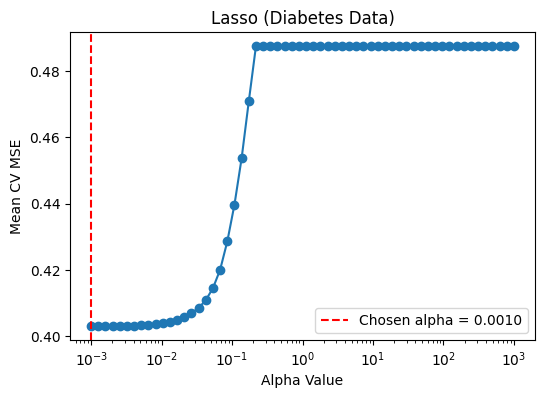

In [8]:
import matplotlib.pyplot as plt

lasso = model_lasso.named_steps["lassocv"]

plt.figure(figsize=(6,4))
plt.plot(lasso.alphas_, lasso.mse_path_.mean(axis=1), marker="o")
plt.axvline(lasso.alpha_, color="red", linestyle="--", 
            label=f"Chosen alpha = {lasso.alpha_:.4f}")
plt.xscale("log")   # log scale for alpha
plt.xlabel("Alpha Value")
plt.ylabel("Mean CV MSE")
plt.title("Lasso (Diabetes Data)")
plt.legend()
plt.ticklabel_format(style="plain", axis="y")  # cleaner y-axis
plt.show()

In [9]:
#Ridge for diabetes data

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline

# X and y-->separate
X = df_diabetes.drop(columns=["Diabetes_012"])
y = df_diabetes["Diabetes_012"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Ridge with CV: alphas included
alphas = np.logspace(-3, 3, 40)  #0.001 to 1000 looking at this
model_ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, cv=5))

# Fit ridge
model_ridge.fit(X_train, y_train)

# Evaluate the model
print("Test R^2:", model_ridge.score(X_test, y_test))
print("Best alpha:", model_ridge.named_steps["ridgecv"].alpha_)

# Coefficients viewed
coefs = pd.Series(model_ridge.named_steps["ridgecv"].coef_, index=X.columns)
print("Top features:\n", coefs.abs().sort_values(ascending=False).head(10))

Test R^2: 0.16999186449408932
Best alpha: 345.5107294592218
Top features:
 GenHlth                 0.106409
BMI                     0.095729
HighBP                  0.077015
HighChol                0.059136
Age                     0.048402
HeartDiseaseorAttack    0.039030
DiffWalk                0.032243
Income                  0.029070
HvyAlcoholConsump       0.023442
CholCheck               0.017950
dtype: float64


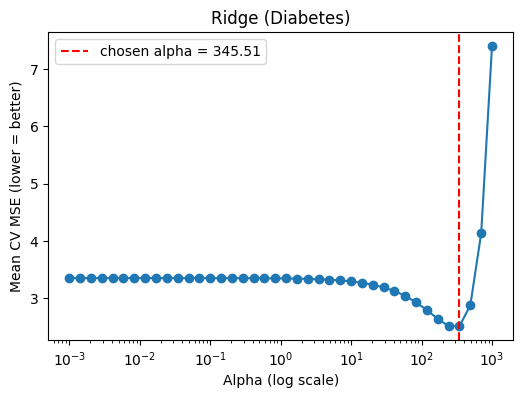

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

#same alphas RidgeCV
alphas = np.logspace(-3, 3, 40)

mean_mse = []
for a in alphas:
    pipe = make_pipeline(StandardScaler(), Ridge(alpha=a))
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="neg_mean_squared_error")
    mean_mse.append(-scores.mean())

best_alpha = model_ridge.named_steps["ridgecv"].alpha_

plt.figure(figsize=(6,4))
plt.plot(alphas, mean_mse, marker="o")
plt.axvline(best_alpha, color="red", linestyle="--", label=f"chosen alpha = {best_alpha:.2f}")
plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Mean CV MSE (lower = better)")
plt.title("Ridge (Diabetes)")
plt.legend()
plt.gca().get_yaxis().get_offset_text().set_visible(False)
plt.show()

In [11]:
#elastic net regression for diabetes data
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import make_pipeline

# X, y-->separate
X = df_diabetes.drop(columns=["Diabetes_012"])
y = df_diabetes["Diabetes_012"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Elastic Net with cross-validation: alpha and L1_ratio
#Regularization strength: Grid
alphas = np.logspace(-3, 3, 60)
#l1_ratio: 0 = Ridge, 1 = Lasso, in-between = both
l1_grid = np.linspace(0.05, 0.95, 10) 

model_elastic_net = make_pipeline(
    StandardScaler(),
    ElasticNetCV(alphas=alphas, l1_ratio=l1_grid, cv=5, random_state=42, max_iter=10000)
)

model_elastic_net.fit(X_train, y_train)

# Performance and best hyperparameters
print("Elastic Net Test R^2:", model_elastic_net.score(X_test, y_test))
en = model_elastic_net.named_steps["elasticnetcv"]
print("Best alpha:", en.alpha_)
print("Best L1_ratio:", en.l1_ratio_)

# Coefficients (non-zero features will come first)
coefs = pd.Series(en.coef_, index=X.columns)
print("\nTop features:\n", coefs[coefs != 0].abs().sort_values(ascending=False).head(10))

Elastic Net Test R^2: 0.16998330126132466
Best alpha: 0.001
Best L1_ratio: 0.15

Top features:
 GenHlth                 0.106413
BMI                     0.095718
HighBP                  0.077035
HighChol                0.059081
Age                     0.048399
HeartDiseaseorAttack    0.038971
DiffWalk                0.032123
Income                  0.028945
HvyAlcoholConsump       0.023353
CholCheck               0.017843
dtype: float64


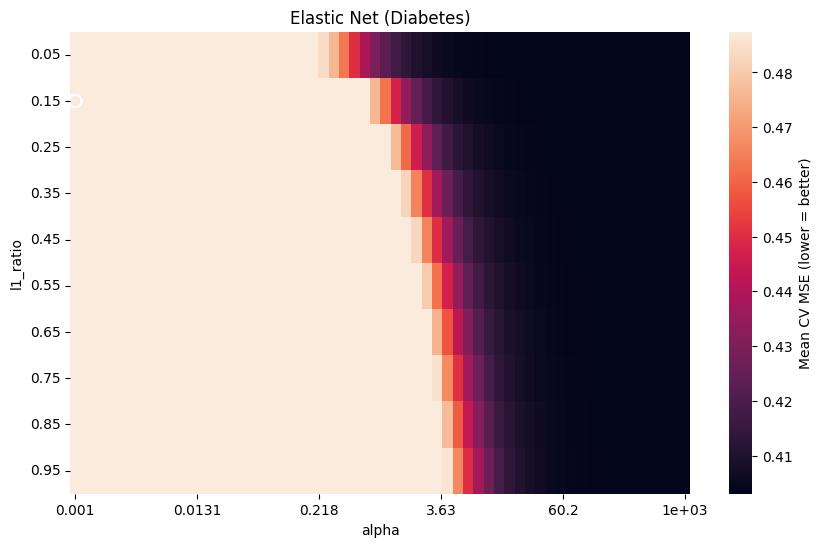

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

en = model_elastic_net.named_steps["elasticnetcv"]

# Average CV error over folds -> shape: (n_l1_ratio, n_alphas)
mse = en.mse_path_.mean(axis=2)

#DataFrame for a heatmap
heatmap_data = pd.DataFrame(mse, index=en.l1_ratio, columns=en.alphas)

plt.figure(figsize=(10,6))
ax = sns.heatmap(
    heatmap_data,
    cbar_kws={"label": "Mean CV MSE (lower = better)"},
)

ax.set_xlabel("alpha")
ax.set_ylabel("l1_ratio")
ax.set_title("Elastic Net (Diabetes)")

# l1_ratio, alpha
row = np.argmin(np.abs(en.l1_ratio - en.l1_ratio_))
col = np.argmin(np.abs(en.alphas   - en.alpha_))
ax.scatter(col + 0.5, row + 0.5, s=80, edgecolor="white", facecolor="none", linewidth=1.5)

#alpha labels (log-spaced)
ax.set_xticks(np.linspace(0.5, heatmap_data.shape[1]-0.5, 6))
xt_idx = np.linspace(0, heatmap_data.shape[1]-1, 6, dtype=int)
ax.set_xticklabels([f"{en.alphas[i]:.3g}" for i in xt_idx], rotation=0)

#plt.tight_layout()
ax.set_yticklabels([f"{val:.2f}" for val in heatmap_data.index])
plt.show()

In [13]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

# predictions
y_pred_lasso = model_lasso.predict(X_test)
y_pred_ridge = model_ridge.predict(X_test)
y_pred_en    = model_elastic_net.predict(X_test)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = pd.DataFrame({
    "Model": ["Lasso", "Ridge", "Elastic Net"],
    "Test R^2": [
        model_lasso.score(X_test, y_test),
        model_ridge.score(X_test, y_test),
        model_elastic_net.score(X_test, y_test)
    ],
    "Test RMSE": [
        rmse(y_test, y_pred_lasso),
        rmse(y_test, y_pred_ridge),
        rmse(y_test, y_pred_en)
    ],
    "Best alpha": [
        model_lasso.named_steps["lassocv"].alpha_,
        model_ridge.named_steps["ridgecv"].alpha_,
        model_elastic_net.named_steps["elasticnetcv"].alpha_
    ],
    "Best l1_ratio": [
        1.0,  # Lasso = pure L1
        0.0,  # Ridge = pure L2
        model_elastic_net.named_steps["elasticnetcv"].l1_ratio_
    ]
})

print(results)

         Model  Test R^2  Test RMSE  Best alpha  Best l1_ratio
0        Lasso  0.169924   0.636074    0.001000           1.00
1        Ridge  0.169992   0.636047  345.510729           0.00
2  Elastic Net  0.169983   0.636051    0.001000           0.15


## Diabetes Dataset Conclusion

The three regularized regression models produced very similar results for the diabetes dataset, with Test R² around 0.17 and RMSE around 0.64. This suggests that Lasso, Ridge, and Elastic Net captured only a limited amount of variation in the diabetes outcome category.

Ridge and Elastic Net performed slightly better than Lasso by RMSE, but the differences were very small. These results suggest that regularized linear regression can provide a useful baseline, but more advanced classification approaches may be better suited for predicting diabetes risk categories.


## Life Expectancy Dataset Modeling

This section uses the life expectancy dataset to model life expectancy as a continuous healthcare outcome. Lasso, Ridge, and Elastic Net are compared to evaluate predictive performance, regularization behavior, and important model coefficients.


In [14]:
#Life Expectancy Dataset
df_life = pd.read_csv("Life Expectancy Data.csv")
df_life.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [15]:
print(df_life.shape)

(2938, 22)


In [16]:
df_life.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [17]:
df_life.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [18]:
# Check for missing values
print(df_life.isnull().sum())

#see if any missing values exist
print("Any missing values?", df_life.isnull().values.any())

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64
Any missing values? True


In [19]:
import pandas as pd

# Clean column names (strip spaces)
df_life.columns = df_life.columns.str.strip()

#missing target rows dropped
df_life = df_life.dropna(subset=["Life expectancy"])

#Separate numeric and categorical columns
num_cols = df_life.select_dtypes(include="number").columns
cat_cols = df_life.select_dtypes(exclude="number").columns

#Impute missing values
# Numeric missing becomes median, Categorical missing becomes mode
df_life[num_cols] = df_life[num_cols].fillna(df_life[num_cols].median())
for c in cat_cols:
    if df_life[c].isnull().any():
        df_life[c] = df_life[c].fillna(df_life[c].mode().iloc[0])

#Check the results
print("Missing values after cleaning:\n", df_life.isnull().sum().sort_values(ascending=False))
print("Final shape:", df_life.shape)

Missing values after cleaning:
 Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
BMI                                0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
HIV/AIDS                           0
GDP                                0
Population                         0
thinness  1-19 years               0
thinness 5-9 years                 0
Income composition of resources    0
Schooling                          0
dtype: int64
Final shape: (2928, 22)


In [20]:
#Life data for lasso

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

#X and y split
X = df_life.drop(columns=["Life expectancy", "Country", "Status"])
y = df_life["Life expectancy"]

#Train/Test model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Lasso with Cross-Validation
alphas = np.logspace(-3, 3, 60)
model_lasso = make_pipeline(
    StandardScaler(),
    LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000)
)

#Fit model
model_lasso.fit(X_train, y_train)

#Evaluate model
y_pred = model_lasso.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"Lasso Test R^2: {r2:.3f}")
print(f"Lasso Test RMSE: {rmse:.3f}")

lasso = model_lasso.named_steps["lassocv"]
print("Best alpha:", lasso.alpha_)

#Show top features
coefs = pd.Series(lasso.coef_, index=X.columns)
print("\nTop features:\n", coefs[coefs != 0].abs().sort_values(ascending=False).head(10))

Lasso Test R^2: 0.816
Lasso Test RMSE: 3.993
Best alpha: 0.0032245905452963947

Top features:
 under-five deaths                  10.240093
infant deaths                      10.096903
Adult Mortality                     2.593705
HIV/AIDS                            2.498536
Schooling                           2.190246
Income composition of resources     1.148473
Diphtheria                          0.965658
BMI                                 0.825797
Polio                               0.727322
GDP                                 0.608077
dtype: float64


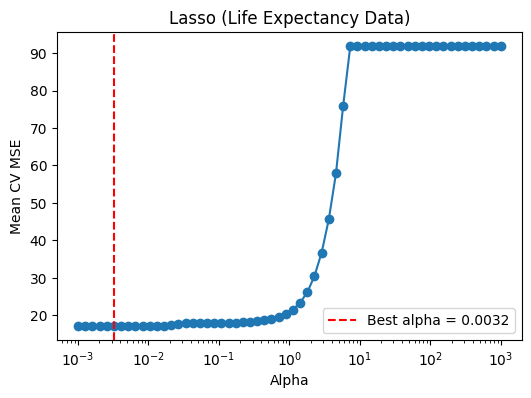

In [21]:
import matplotlib.pyplot as plt

lasso = model_lasso.named_steps["lassocv"]

plt.figure(figsize=(6,4))
plt.plot(lasso.alphas_, lasso.mse_path_.mean(axis=1), marker="o")
plt.axvline(lasso.alpha_, color="red", linestyle="--", 
            label=f"Best alpha = {lasso.alpha_:.4f}")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Mean CV MSE")
plt.title("Lasso (Life Expectancy Data)")
plt.legend()
plt.ticklabel_format(style="plain", axis="y") 
plt.show()

In [22]:
#life data for ridge
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

#X and y split
X = df_life.drop(columns=["Life expectancy", "Country", "Status"])
y = df_life["Life expectancy"]

#Train and test split to train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Ridge with CV
alphas = np.logspace(-3, 3, 60)
model_ridge = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=alphas, cv=5)
)

#Fit model
model_ridge.fit(X_train, y_train)

#Evaluate the model
y_pred = model_ridge.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"Ridge Test R^2: {r2:.3f}")
print(f"Ridge Test RMSE: {rmse:.3f}")
print("Best alpha:", model_ridge.named_steps["ridgecv"].alpha_)

#Top Features as result
coefs = pd.Series(model_ridge.named_steps["ridgecv"].coef_, index=X.columns)
print("\nTop features:\n", coefs.abs().sort_values(ascending=False).head(10))

Ridge Test R^2: 0.816
Ridge Test RMSE: 3.994
Best alpha: 0.34863652276780877

Top features:
 under-five deaths                  10.776210
infant deaths                      10.639479
Adult Mortality                     2.591154
HIV/AIDS                            2.498735
Schooling                           2.186125
Income composition of resources     1.142709
Diphtheria                          0.960975
BMI                                 0.826679
Polio                               0.725741
GDP                                 0.615242
dtype: float64


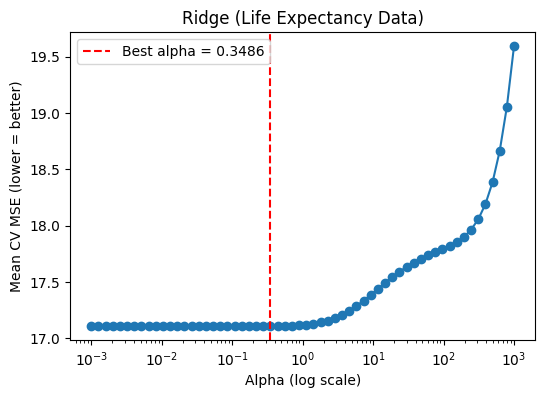

In [23]:
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

#same alpha grid as RidgeCV
alphas = np.logspace(-3, 3, 60)

#mean CV MSE for each alpha
mean_mse = []
for a in alphas:
    pipe = make_pipeline(StandardScaler(), Ridge(alpha=a))
    scores = cross_val_score(pipe, X_train, y_train, cv=5,
                             scoring="neg_mean_squared_error")
    mean_mse.append(-scores.mean())

#best alpha chosen by RidgeCV
ridge = model_ridge.named_steps["ridgecv"]
best_alpha = ridge.alpha_

# Plot
plt.figure(figsize=(6,4))
plt.plot(alphas, mean_mse, marker="o")
plt.axvline(best_alpha, color="red", linestyle="--",
            label=f"Best alpha = {best_alpha:.4f}")
plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Mean CV MSE (lower = better)")
plt.title("Ridge (Life Expectancy Data)")
plt.legend()
plt.ticklabel_format(style="plain", axis="y")
plt.show()

In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

#X and y (drop non-numeric)
X = df_life.drop(columns=["Life expectancy", "Country", "Status"])
y = df_life["Life expectancy"]

#split for test and train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Elastic Net with CV
alphas   = np.logspace(-3, 3, 60)          # 0.001 to 1000
l1_grid  = np.linspace(0.05, 0.95, 10)     # 0=ridge and 1=lasso

model_elastic_net = make_pipeline(
    StandardScaler(),
    ElasticNetCV(alphas=alphas, l1_ratio=l1_grid, cv=5,
                 random_state=42, max_iter=10000)
)

#fit & evaluate model
model_elastic_net.fit(X_train, y_train)
y_pred = model_elastic_net.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"Elastic Net Test R^2: {r2:.3f}")
print(f"Elastic Net Test RMSE: {rmse:.3f}")

en = model_elastic_net.named_steps["elasticnetcv"]
print("Best alpha:", en.alpha_)
print("Best l1_ratio:", en.l1_ratio_)

coefs = pd.Series(en.coef_, index=X.columns)
print(coefs[coefs != 0].abs().sort_values(ascending=False).head(10))


Elastic Net Test R^2: 0.816
Elastic Net Test RMSE: 3.993
Best alpha: 0.001597312280060254
Best l1_ratio: 0.95
under-five deaths                  10.529202
infant deaths                      10.390038
Adult Mortality                     2.592230
HIV/AIDS                            2.498521
Schooling                           2.188040
Income composition of resources     1.145441
Diphtheria                          0.963253
BMI                                 0.825724
Polio                               0.726362
GDP                                 0.611728
dtype: float64


Elastic Net Test R^2: 0.814 and RMSE: 4.008
Best alpha: 0.01
Best l1_ratio: 0.95


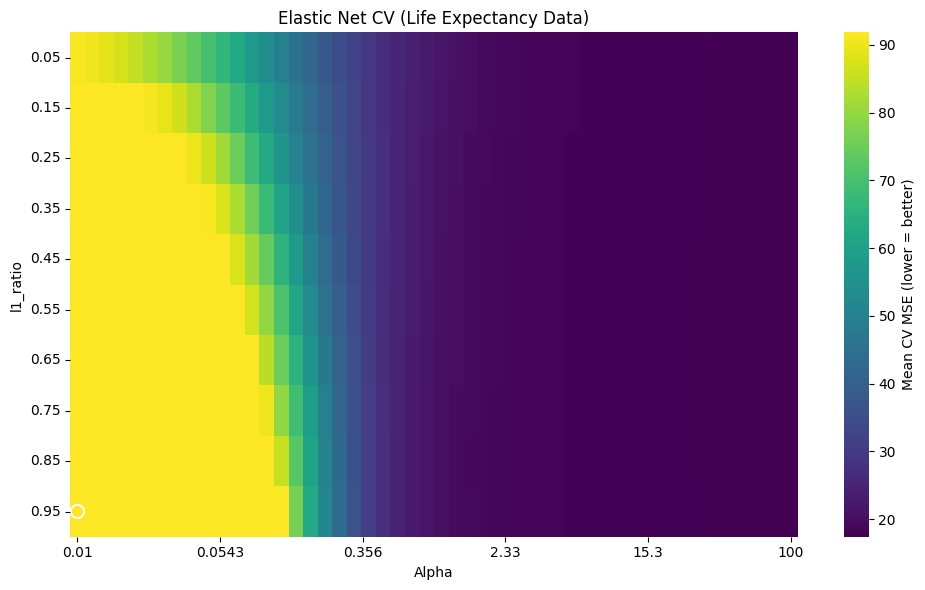

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Clean headers
df_life.columns = df_life.columns.str.strip()

#X and y (drop target and non-numeric) 
X = df_life.drop(columns=["Life expectancy", "Country", "Status"])
y = df_life["Life expectancy"]

# Split test/train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Elastic Net with CV 
alphas  = np.logspace(-2, 2, 50)          # 0.01 to 100 for heatmap well-scaled
l1_grid = np.linspace(0.05, 0.95, 10)     # 10 values between Ridge: 0 and Lasso: 1

model_en = make_pipeline(
    StandardScaler(),
    ElasticNetCV(
        alphas=alphas,
        l1_ratio=l1_grid,
        cv=5,
        random_state=42,
        max_iter=10000
    )
)

model_en.fit(X_train, y_train)

# Evaluate 
en = model_en.named_steps["elasticnetcv"]
y_pred = model_en.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
print(f"Elastic Net Test R^2: {r2:.3f} and RMSE: {rmse:.3f}")
print("Best alpha:", en.alpha_)
print("Best l1_ratio:", en.l1_ratio_)

# heatmap data
# mse_path_ shape
mse = en.mse_path_.mean(axis=2) 

heatmap_data = pd.DataFrame(mse, index=en.l1_ratio, columns=en.alphas)

# Plot heatmap with contrast
plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    heatmap_data,
    cmap="viridis",
    cbar_kws={"label": "Mean CV MSE (lower = better)"},
    robust=True  
)

# Mark the chosen for l1_ratio, alpha
row = np.argmin(np.abs(en.l1_ratio - en.l1_ratio_))
col = np.argmin(np.abs(en.alphas   - en.alpha_))
ax.scatter(col + 0.5, row + 0.5, s=90, edgecolor="white", facecolor="none", linewidth=1.5)

ax.set_title("Elastic Net CV (Life Expectancy Data)")
ax.set_xlabel("Alpha")
ax.set_ylabel("l1_ratio")
ax.set_yticklabels([f"{v:.2f}" for v in heatmap_data.index])

num_cols = heatmap_data.shape[1]
tick_positions = np.linspace(0.5, num_cols - 0.5, 6)
tick_indices = np.linspace(0, num_cols - 1, 6, dtype=int)
ax.set_xticks(tick_positions)
ax.set_xticklabels([f"{en.alphas[i]:.3g}" for i in tick_indices], rotation=0)

plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

#Predictions for the models
y_pred_lasso = model_lasso.predict(X_test)
y_pred_ridge = model_ridge.predict(X_test)
y_pred_en    = model_elastic_net.predict(X_test)

#Metric values
r2_lasso  = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

r2_ridge  = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

r2_en  = r2_score(y_test, y_pred_en)
rmse_en = np.sqrt(mean_squared_error(y_test, y_pred_en))

#Best hyperparameters for the models
lasso = model_lasso.named_steps["lassocv"]
ridge = model_ridge.named_steps["ridgecv"]
en    = model_elastic_net.named_steps["elasticnetcv"]

#Summary table of the results
results = pd.DataFrame({
    "Model": ["Lasso", "Ridge", "Elastic Net"],
    "Test R^2": [r2_lasso, r2_ridge, r2_en],
    "Test RMSE": [rmse_lasso, rmse_ridge, rmse_en],
    "Best alpha": [lasso.alpha_, ridge.alpha_, en.alpha_],
    "Best l1_ratio": [1.0, 0.0, en.l1_ratio_]  # 1.0 for Lasso, 0.0 for Ridge
})

print(results)

         Model  Test R^2  Test RMSE  Best alpha  Best l1_ratio
0        Lasso  0.815630   3.993486    0.003225           1.00
1        Ridge  0.815623   3.993560    0.348637           0.00
2  Elastic Net  0.815632   3.993461    0.001597           0.95


## Life Expectancy Dataset Conclusion

The life expectancy models performed similarly across Lasso, Ridge, and Elastic Net, with Test R² around 0.82 and RMSE around 4 years. This suggests that the regularized regression models were able to explain a substantial amount of variation in life expectancy.

Elastic Net had the lowest RMSE by a very small margin and used a high L1 ratio, making it behave similarly to Lasso while still retaining some Ridge-style stability. Overall, Elastic Net is a reasonable choice for this dataset, although all three models performed nearly the same.


## SUPPORT2 Dataset Modeling

This section uses the SUPPORT2 dataset to model hospital days as a continuous healthcare outcome. Regularized regression models are compared to assess prediction performance and evaluate how the models handle many clinical variables.


In [27]:
#Support2 Dataset
df_support = pd.read_csv("support2.csv")
df_support.head()

,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,...,ph,glucose,bun,urine,adlp,adls,adlsc,death,hospdead,sfdm2
0,62.84998,male,Lung Cancer,Cancer,0,11.0,$11-$25k,0.0,9715.0,NaN,...,7.459961,NaN,NaN,NaN,7.0,7.0,7.0,0,0,NaN
1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,$11-$25k,44.0,34496.0,NaN,...,7.250000,NaN,NaN,NaN,NaN,1.0,1.0,1,1,<2 mo. follow-up
2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,under $11k,0.0,41094.0,NaN,...,7.459961,NaN,NaN,NaN,1.0,0.0,0.0,1,0,<2 mo. follow-up
3,42.38498,female,Lung Cancer,Cancer,2,11.0,under $11k,0.0,3075.0,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1,0,no(M2 and SIP pres)
4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,26.0,50127.0,NaN,...,7.509766,NaN,NaN,NaN,NaN,2.0,2.0,0,0,no(M2 and SIP pres)


In [28]:
print(df_support.shape)

(9105, 45)


In [29]:
df_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 45 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       9105 non-null   float64
 1   sex       9105 non-null   object 
 2   dzgroup   9105 non-null   object 
 3   dzclass   9105 non-null   object 
 4   num.co    9105 non-null   int64  
 5   edu       7471 non-null   float64
 6   income    6123 non-null   object 
 7   scoma     9104 non-null   float64
 8   charges   8933 non-null   float64
 9   totcst    8217 non-null   float64
 10  totmcst   5630 non-null   float64
 11  avtisst   9023 non-null   float64
 12  race      9063 non-null   object 
 13  sps       9104 non-null   float64
 14  aps       9104 non-null   float64
 15  surv2m    9104 non-null   float64
 16  surv6m    9104 non-null   float64
 17  hday      9105 non-null   int64  
 18  diabetes  9105 non-null   int64  
 19  dementia  9105 non-null   int64  
 20  ca        9105 non-null   obje

In [30]:
df_support.describe()

,age,num.co,edu,scoma,charges,totcst,totmcst,avtisst,sps,aps,...,sod,ph,glucose,bun,urine,adlp,adls,adlsc,death,hospdead
count,9105.000000,9105.000000,7471.000000,9104.000000,8.933000e+03,8217.000000,5630.000000,9023.000000,9104.000000,9104.000000,...,9104.000000,6821.000000,4605.000000,4753.000000,4243.000000,3464.000000,6238.000000,9105.000000,9105.000000,9105.000000
mean,62.650823,1.868644,11.747691,12.058546,5.999579e+04,30825.867768,28828.877838,22.610928,25.525872,37.597979,...,137.568541,7.415364,159.873398,32.349463,2191.546047,1.157910,1.637384,1.888272,0.681054,0.259198
std,15.593710,1.344409,3.447743,24.636694,1.026488e+05,45780.820986,43604.261932,13.233248,9.899377,19.903852,...,6.029326,0.080563,88.391541,26.792288,1455.245777,1.739672,2.231358,2.003763,0.466094,0.438219
min,18.041990,0.000000,0.000000,0.000000,1.169000e+03,0.000000,-102.719970,1.000000,0.199982,0.000000,...,110.000000,6.829102,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,52.797000,1.000000,10.000000,0.000000,9.740000e+03,5929.566400,5177.404300,12.000000,19.000000,23.000000,...,134.000000,7.379883,103.000000,14.000000,1165.500000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,64.856990,2.000000,12.000000,0.000000,2.502400e+04,14452.734400,13223.500000,19.500000,23.898438,34.000000,...,137.000000,7.419922,135.000000,23.000000,1968.000000,0.000000,1.000000,1.000000,1.000000,0.000000
75%,73.998960,3.000000,14.000000,9.000000,6.459800e+04,36087.937500,34223.601600,31.666656,30.199219,49.000000,...,141.000000,7.469727,188.000000,42.000000,3000.000000,2.000000,3.000000,3.000000,1.000000,1.000000
max,101.847960,9.000000,31.000000,100.000000,1.435423e+06,633212.000000,710682.000000,83.000000,99.187500,143.000000,...,181.000000,7.769531,1092.000000,300.000000,9000.000000,7.000000,7.000000,7.073242,1.000000,1.000000


In [31]:
# Check for missing values
print(df_support.isnull().sum())

#see if any missing values exist
print("Any missing values?", df_support.isnull().values.any())

age            0
sex            0
dzgroup        0
dzclass        0
num.co         0
edu         1634
income      2982
scoma          1
charges      172
totcst       888
totmcst     3475
avtisst       82
race          42
sps            1
aps            1
surv2m         1
surv6m         1
hday           0
diabetes       0
dementia       0
ca             0
prg2m       1649
prg6m       1633
dnr           30
dnrday        30
meanbp         1
wblc         212
hrt            1
resp           1
temp           1
pafi        2325
alb         3372
bili        2601
crea          67
sod            1
ph          2284
glucose     4500
bun         4352
urine       4862
adlp        5641
adls        2867
adlsc          0
death          0
hospdead       0
sfdm2       1400
dtype: int64
Any missing values? True


In [32]:
import pandas as pd

# Load and tidy headers
df_support = pd.read_csv("support2.csv")
df_support.columns = df_support.columns.str.strip()

#target
TARGET = "hday"   # hospital days

#Drop rows with missing target
if TARGET not in df_support.columns:
    raise ValueError(f"Expected a '{TARGET}' column in support2.csv.")
rows_before = df_support.shape[0]
df_support = df_support.dropna(subset=[TARGET])
print(f"Dropped {rows_before - df_support.shape[0]} rows with missing {TARGET}.")

#Impute missing values
num_cols = df_support.select_dtypes(include="number").columns
cat_cols = df_support.select_dtypes(exclude="number").columns

# Numeric missing becomes median
df_support[num_cols] = df_support[num_cols].fillna(df_support[num_cols].median())

# Categorical missing becomes mode (fills only the missing cells)
for c in cat_cols:
    if df_support[c].isna().any():
        df_support[c] = df_support[c].fillna(df_support[c].mode().iloc[0])

print("Total missing after:", int(df_support.isna().sum().sum()))
print("Shape after cleaning:", df_support.shape)

Dropped 0 rows with missing hday.
Total missing after: 0
Shape after cleaning: (9105, 45)


In [33]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

#target
TARGET = "hday"  # hospital days (regression)

# X, y: keep numeric features only
X = df_support.drop(columns=[TARGET]).select_dtypes(include="number")
y = df_support[TARGET].astype(float)

# train and test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Lasso with cross-validation
alphas = np.logspace(-3, 3, 60)  # 0.001 to 1000
model_lasso = make_pipeline(
    StandardScaler(),
    LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=20000)
)

# fit model
model_lasso.fit(X_train, y_train)

# evaluate the model
y_pred = model_lasso.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

lasso = model_lasso.named_steps["lassocv"]
print(f"Lasso Test R^2: {r2:.3f}")
print(f"Lasso Test RMSE: {rmse:.3f}")
print("Best alpha:", lasso.alpha_)

# top features: non-zero coefficients
coefs = pd.Series(lasso.coef_, index=X.columns)
top = coefs[coefs != 0].abs().sort_values(ascending=False).head(15)
print("\nTop features:\n", coefs.loc[top.index])

Lasso Test R^2: 0.271
Lasso Test RMSE: 8.161
Best alpha: 0.008227241341700473

Top features:
 surv2m    -6.919226
surv6m     3.723268
charges    3.290231
totcst     2.529143
dnrday    -2.217758
sps       -1.761456
scoma     -1.379317
age       -0.595137
totmcst    0.432717
meanbp     0.358757
avtisst   -0.314292
edu       -0.279111
alb       -0.244041
aps        0.237868
num.co    -0.202149
dtype: float64


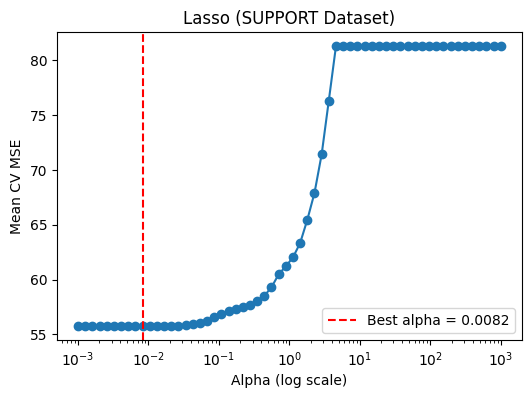

In [34]:
import matplotlib.pyplot as plt

#fitted lasso model from the pipeline
lasso = model_lasso.named_steps["lassocv"]

plt.figure(figsize=(6,4))
plt.plot(lasso.alphas_, lasso.mse_path_.mean(axis=1), marker="o")

# best alpha line
plt.axvline(lasso.alpha_, color="red", linestyle="--",
            label=f"Best alpha = {lasso.alpha_:.4f}")

plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Mean CV MSE")
plt.title("Lasso (SUPPORT Dataset)")
plt.legend()
plt.show()

In [35]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

#target
TARGET = "hday"  # hospital days (regression)

# X, y: numeric only
X = df_support.drop(columns=[TARGET]).select_dtypes(include="number")
y = df_support[TARGET].astype(float)

# train and test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Ridge with cross-validation
alphas = np.logspace(-3, 3, 60)  # 0.001 → 1000
model_ridge = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=alphas, cv=5, scoring="neg_mean_squared_error")
)

# fit model
model_ridge.fit(X_train, y_train)

# evaluate the model
y_pred = model_ridge.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

ridge = model_ridge.named_steps["ridgecv"]
print(f"Ridge Test R^2: {r2:.3f}")
print(f"Ridge Test RMSE: {rmse:.3f}")
print("Best alpha:", ridge.alpha_)

# top 10 features
coefs = pd.Series(ridge.coef_, index=X.columns)
top10 = coefs.abs().sort_values(ascending=False).head(10)
print("\nTop 10 features:\n", coefs.loc[top10.index])

Ridge Test R^2: 0.271
Ridge Test RMSE: 8.163
Best alpha: 9.249147277217336

Top 10 features:
 surv2m    -7.053831
surv6m     3.825555
charges    3.299535
totcst     2.540318
dnrday    -2.231969
sps       -1.806439
scoma     -1.402725
age       -0.615288
totmcst    0.440198
meanbp     0.367945
dtype: float64


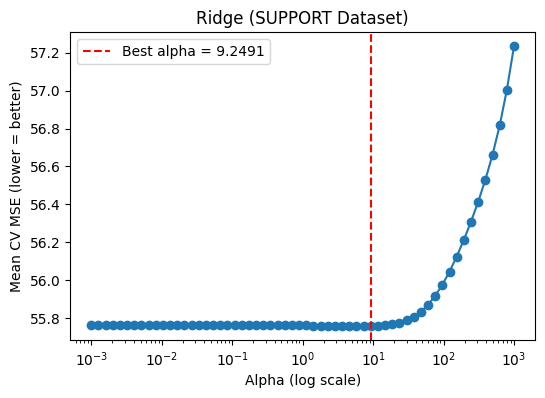

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

ridge = model_ridge.named_steps["ridgecv"]
alphas = ridge.alphas  # same grid used in RidgeCV

mean_mse = []
for a in alphas:
    pipe = make_pipeline(StandardScaler(), Ridge(alpha=a))
    scores = cross_val_score(pipe, X_train, y_train, cv=5,
                             scoring="neg_mean_squared_error")
    mean_mse.append(-scores.mean())

plt.figure(figsize=(6,4))
plt.plot(alphas, mean_mse, marker="o")
plt.axvline(ridge.alpha_, color="red", linestyle="--",
            label=f"Best alpha = {ridge.alpha_:.4f}")
plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Mean CV MSE (lower = better)")
plt.title("Ridge (SUPPORT Dataset)")
plt.legend()
plt.show()

In [37]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

#target
TARGET = "hday"  # hospital days (regression)

# X, y: numeric-only
X = df_support.drop(columns=[TARGET]).select_dtypes(include="number")
y = df_support[TARGET].astype(float)

# train and test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Elastic Net with cross-validation
alphas  = np.logspace(-3, 3, 60)          # 0.001 → 1000
l1_grid = np.linspace(0.05, 0.95, 10)     # 0=ridge … 1=lasso

model_elastic_net = make_pipeline(
    StandardScaler(),
    ElasticNetCV(
        alphas=alphas,
        l1_ratio=l1_grid,
        cv=5,
        random_state=42,
        max_iter=20000
    )
)

# fit model
model_elastic_net.fit(X_train, y_train)

# evaluate model
y_pred = model_elastic_net.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

en = model_elastic_net.named_steps["elasticnetcv"]
print(f"Elastic Net Test R^2: {r2:.3f}")
print(f"Elastic Net Test RMSE: {rmse:.3f}")
print("Best alpha:", en.alpha_)
print("Best l1_ratio:", en.l1_ratio_)

# top 10 features kept: non-zero coefficients
coefs = pd.Series(en.coef_, index=X.columns)
top10 = coefs[coefs != 0].abs().sort_values(ascending=False).head(10)
print("\nTop 10 features:\n", coefs.loc[top10.index])

Elastic Net Test R^2: 0.271
Elastic Net Test RMSE: 8.161
Best alpha: 0.008227241341700473
Best l1_ratio: 0.95

Top 10 features:
 surv2m    -6.818194
surv6m     3.647341
charges    3.288440
totcst     2.528399
dnrday    -2.216933
sps       -1.747777
scoma     -1.364807
age       -0.591960
totmcst    0.434149
meanbp     0.358850
dtype: float64


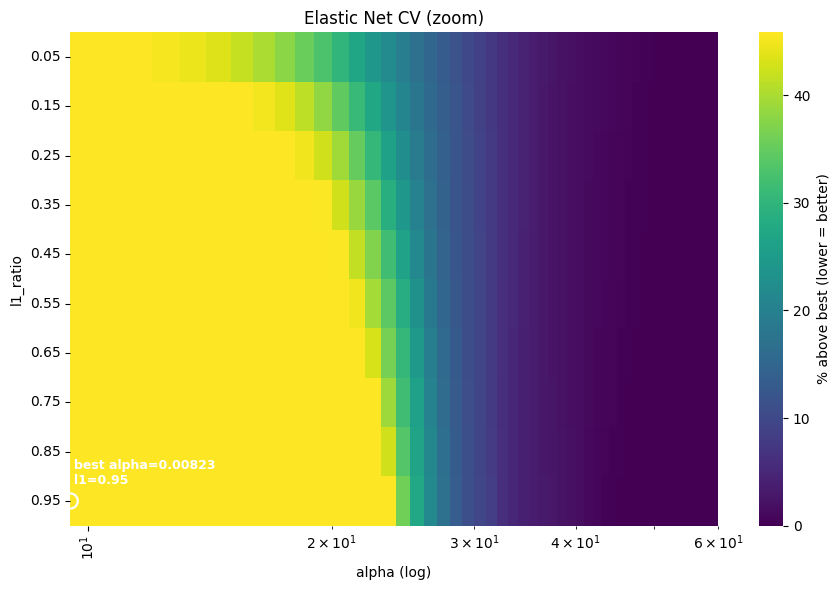

In [38]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt

en = model_elastic_net.named_steps["elasticnetcv"] 

#above best for contrast
mse = en.mse_path_.mean(axis=2)
df  = pd.DataFrame((mse/mse.min()-1)*100, index=en.l1_ratio, columns=en.alphas)

plt.figure(figsize=(9,6))
vmax = max(0.5, np.percentile(df.values, 95)) 
ax = sns.heatmap(df, cmap="viridis", vmin=0, vmax=vmax,
                 cbar_kws={"label": "% above best (lower = better)"})

#mark and label best:  alpha, l1_ratio
ri = int(np.argmin(np.abs(en.l1_ratio - en.l1_ratio_)))
ci = int(np.argmin(np.abs(en.alphas   - en.alpha_)))
ax.scatter(ci+0.5, ri+0.5, s=120, edgecolor="white", facecolor="none", lw=1.6, zorder=5)
ax.text(ci+0.6, ri+0.15, f"best alpha={en.alpha_:.3g}\nl1={en.l1_ratio_:.2f}",
        color="white", fontsize=9, weight="bold")

ax.set_title("Elastic Net CV (zoom)")
ax.set_xlabel("alpha (log)"); ax.set_ylabel("l1_ratio")
# Alpha values are already ordered on the heatmap, so no additional log scaling is needed.
ax.set_yticklabels([f"{v:.2f}" for v in df.index])
plt.tight_layout(); plt.show()

In [39]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd

# predictions
y_pred_lasso = model_lasso.predict(X_test)
y_pred_ridge = model_ridge.predict(X_test)
y_pred_en    = model_elastic_net.predict(X_test)

# fitted steps
lasso = model_lasso.named_steps["lassocv"]
ridge = model_ridge.named_steps["ridgecv"]
en    = model_elastic_net.named_steps["elasticnetcv"] 

# metrics
r2_lasso,  rmse_lasso  = r2_score(y_test, y_pred_lasso), np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_ridge,  rmse_ridge  = r2_score(y_test, y_pred_ridge), np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_en,     rmse_en     = r2_score(y_test, y_pred_en),    np.sqrt(mean_squared_error(y_test, y_pred_en))

# summary table
results = pd.DataFrame({
    "Model":       ["Lasso", "Ridge", "Elastic Net"],
    "Test R^2":    [r2_lasso, r2_ridge, r2_en],
    "Test RMSE":   [rmse_lasso, rmse_ridge, rmse_en],
    "Best alpha":  [lasso.alpha_, ridge.alpha_, en.alpha_],
    "Best l1_ratio": [1.0, 0.0, float(en.l1_ratio_)]
})

results = results.round({"Test R^2":6, "Test RMSE":6, "Best alpha":6, "Best l1_ratio":2})
results = results.sort_values(["Test RMSE", "Test R^2"], ascending=[True, False]).reset_index(drop=True)
print(results)

         Model  Test R^2  Test RMSE  Best alpha  Best l1_ratio
0  Elastic Net  0.271317   8.160909    0.008227           0.95
1        Lasso  0.271284   8.161096    0.008227           1.00
2        Ridge  0.270911   8.163183    9.249147           0.00


## SUPPORT2 Dataset Conclusion

For the SUPPORT2 dataset, the three regularized regression models produced very similar performance, with Test R² around 0.27 and RMSE around 8.16 hospital days. This indicates that the models explained only a modest amount of variation in hospital length of stay.

Elastic Net performed slightly best, with Lasso nearly identical and Ridge slightly behind. These results suggest that regularized linear regression is useful as a baseline, but more advanced or non-linear models may be needed to improve hospital-day prediction.
